In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [76]:
path = "../../data/raw/crops/CMO-Historical-Data-Annual.xlsx"
xls = pd.ExcelFile(path)
print(xls.sheet_names)

['Cover', 'Annual Prices (Nominal)', 'Annual Indices (Nominal)', 'Annual Prices (Real)', 'Annual Indices (Real)', 'Description', 'Definitions', 'Index Weights']


In [77]:
df = pd.read_excel(xls, sheet_name="Annual Prices (Nominal)",  header=6, skiprows=[7], na_values="…")
df = df.rename(columns={df.columns[0]: "year"})
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df[df["year"] >= 1996].reset_index(drop=True)
df.head()


,year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,1996,20.4,20.7,18.5,22.1,38.1,33.5,2.73,2.84,3.67,...,1506,30.0,2295,774,6165,7501,1025,388,397,5.2
1,1997,19.2,19.1,18.1,20.3,35.1,31.3,2.48,2.74,3.91,...,1599,30.2,2277,624,5647,6927,1316,331,395,4.9
2,1998,13.1,12.7,12.1,14.3,29.2,26.8,2.09,2.42,3.02,...,1357,31.0,1654,529,5540,4630,1024,294,372,5.6
3,1999,18.1,17.8,17.2,19.2,25.9,24.3,2.27,2.13,3.14,...,1361,27.6,1573,503,5404,6011,1076,279,377,5.2
4,2000,28.2,28.3,26.1,30.3,26.3,26.6,4.31,3.86,4.71,...,1549,28.8,1813,454,5436,8638,1128,279,545,5.0


In [78]:
df_real = pd.read_excel(xls, sheet_name="Annual Prices (Real)",  header=6, skiprows=[7], na_values="…")
df_real = df_real.rename(columns={df_real.columns[0]: "year"})
df_real["year"] = pd.to_numeric(df_real["year"], errors="coerce")
df_real = df_real[df_real["year"] >= 1996].reset_index(drop=True)
df_real.head()


,year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,"Iron ore, cfr spot",Copper,Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver,MUV Index
0,1996,22.6,22.9,20.6,24.5,42.2,37.2,3.03,3.15,4.07,...,33.3,2545,859,6837,8319,1137,430,440,5.8,90.2
1,1997,22.3,22.2,21.1,23.7,40.8,36.5,2.89,3.19,4.55,...,35.1,2650,726,6572,8062,1532,385,460,5.7,85.9
2,1998,15.9,15.5,14.8,17.5,35.6,32.7,2.54,2.94,3.67,...,37.7,2013,643,6742,5634,1247,358,453,6.8,82.2
3,1999,22.4,22.1,21.3,23.9,32.1,30.1,2.81,2.64,3.89,...,34.2,1952,624,6705,7459,1336,346,468,6.5,80.6
4,2000,35.5,35.5,32.8,38.1,33.0,33.4,5.42,4.85,5.92,...,36.2,2279,571,6832,10857,1418,351,685,6.2,79.6


In [79]:
colonnes = ["year", "Soybeans", "Soybean oil", "Soybean meal", "Palm oil", "Palm kernel oil", "Beef"]
df_sel = df[colonnes]
df_sel.head()


,year,Soybeans,Soybean oil,Soybean meal,Palm oil,Palm kernel oil,Beef
0,1996,305,552,268,531,728.0,1.75
1,1997,295,565,276,546,652.0,1.85
2,1998,243,626,170,671,687.0,1.72
3,1999,202,426,165,436,694.0,1.81
4,2000,212,338,204,310,444.0,1.93


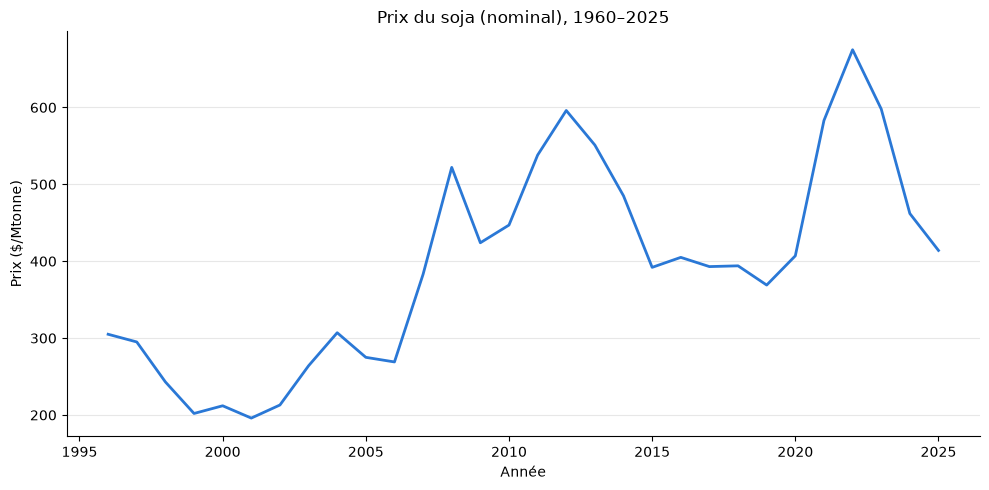

In [80]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybeans"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du soja (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


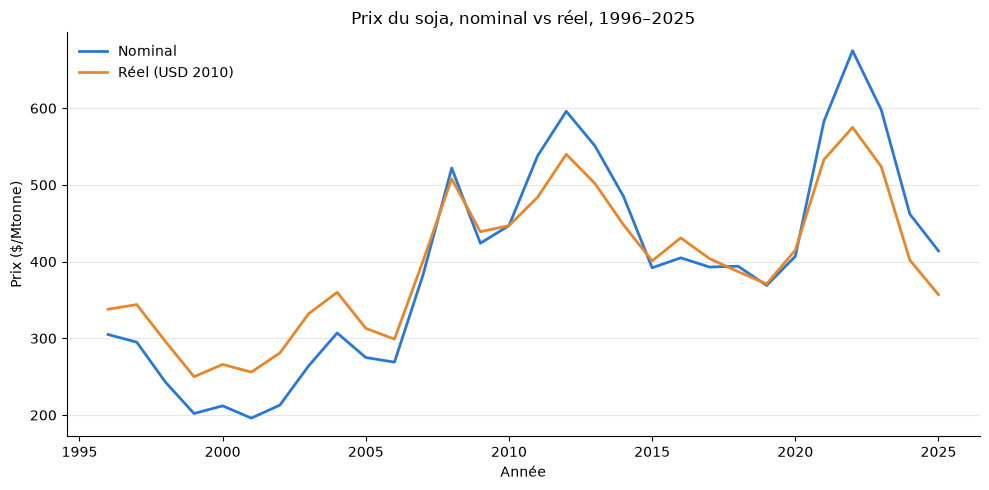

In [81]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybeans"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Soybeans"], color="#e8862a", linewidth=2, label="Réel (USD 2010)")
ax.set_title("Prix du soja, nominal vs réel, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


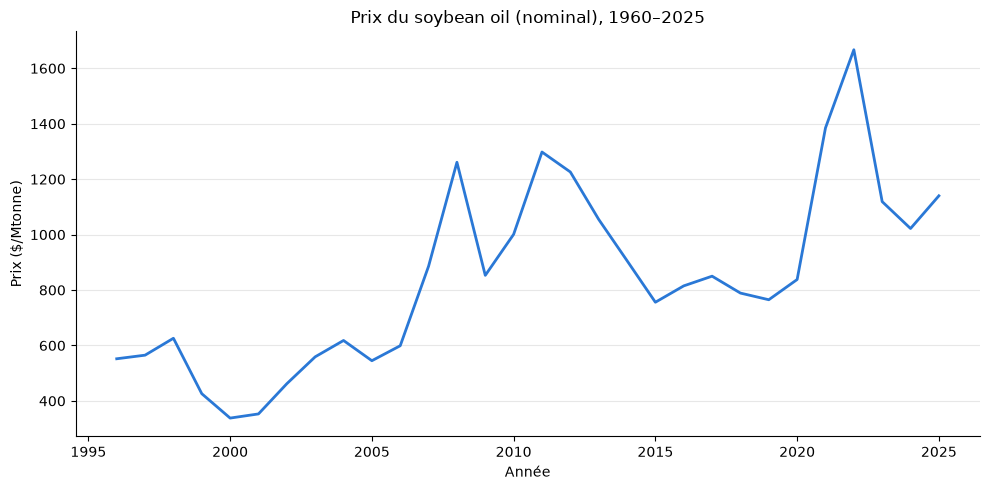

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybean oil"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du soybean oil (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

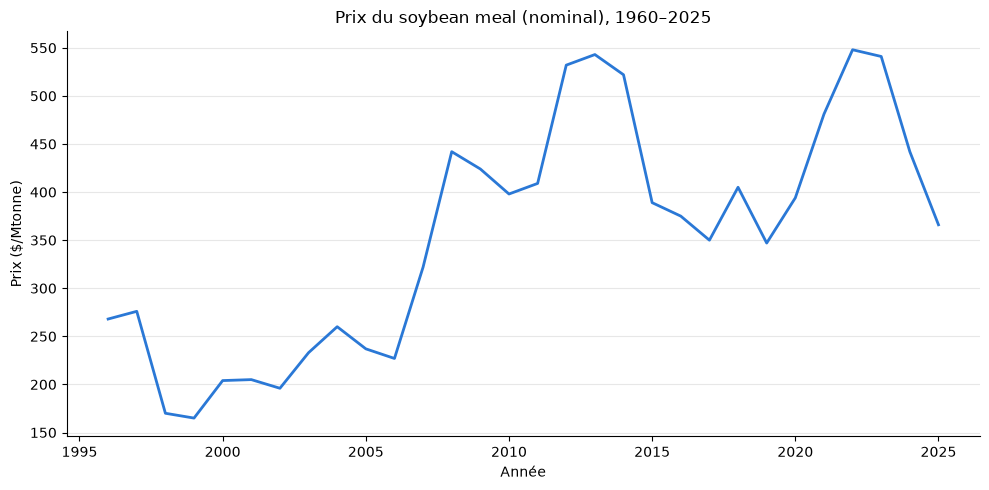

In [83]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Soybean meal"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du soybean meal (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

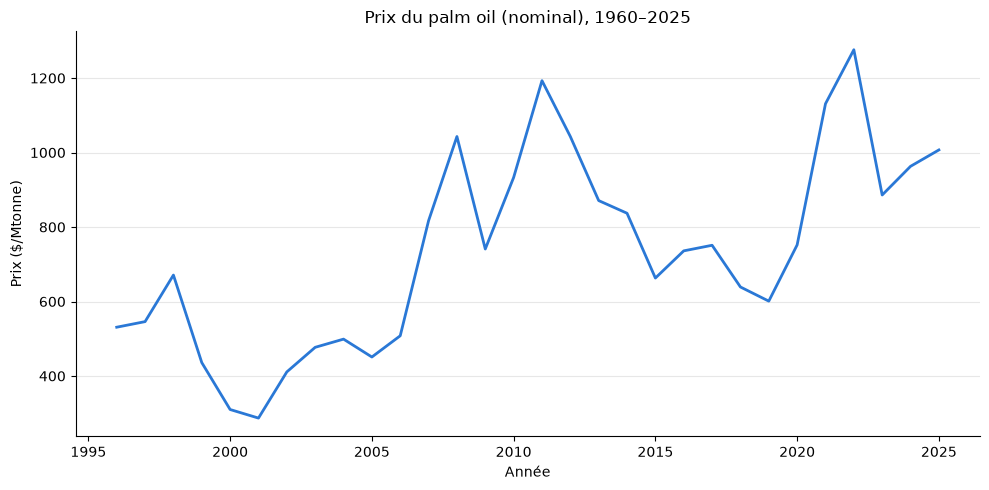

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm oil"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du palm oil (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

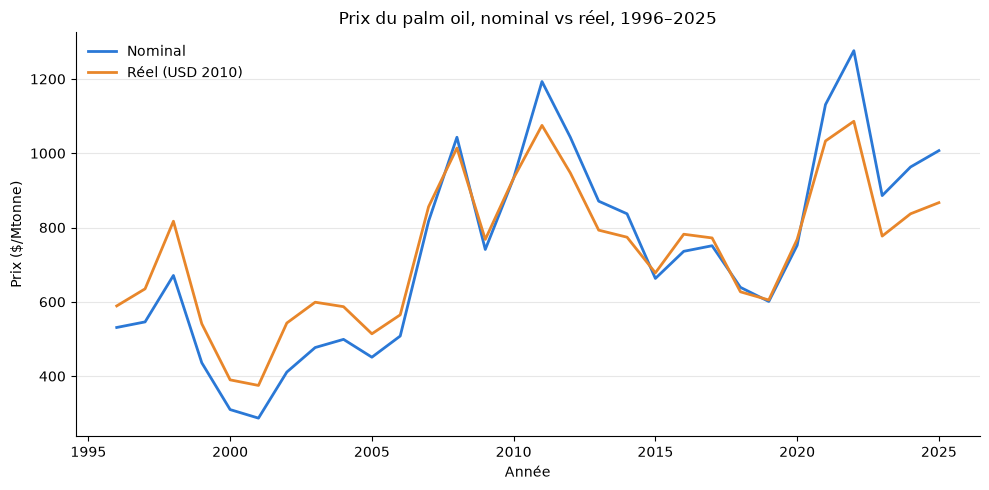

In [85]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm oil"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Palm oil"], color="#e8862a", linewidth=2, label="Réel (USD 2010)")
ax.set_title("Prix du palm oil, nominal vs réel, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

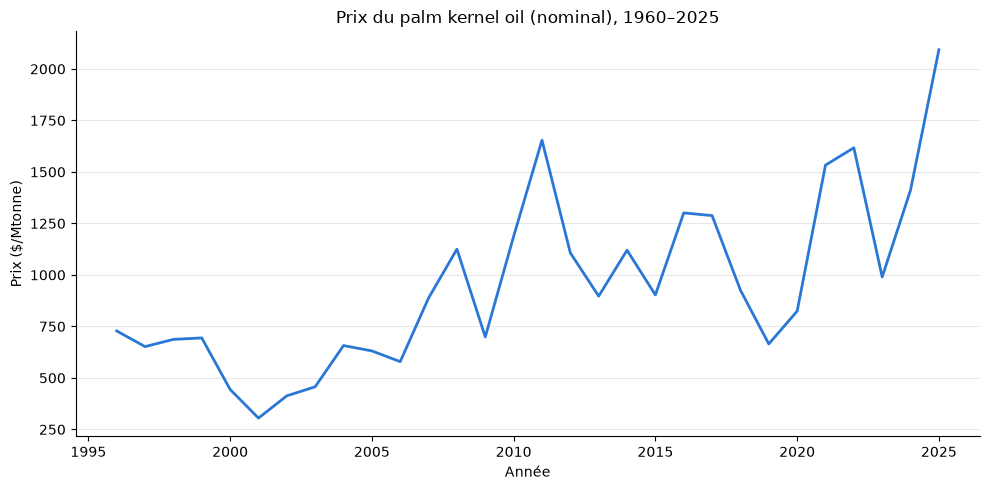

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Palm kernel oil"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du palm kernel oil (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/Mtonne)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

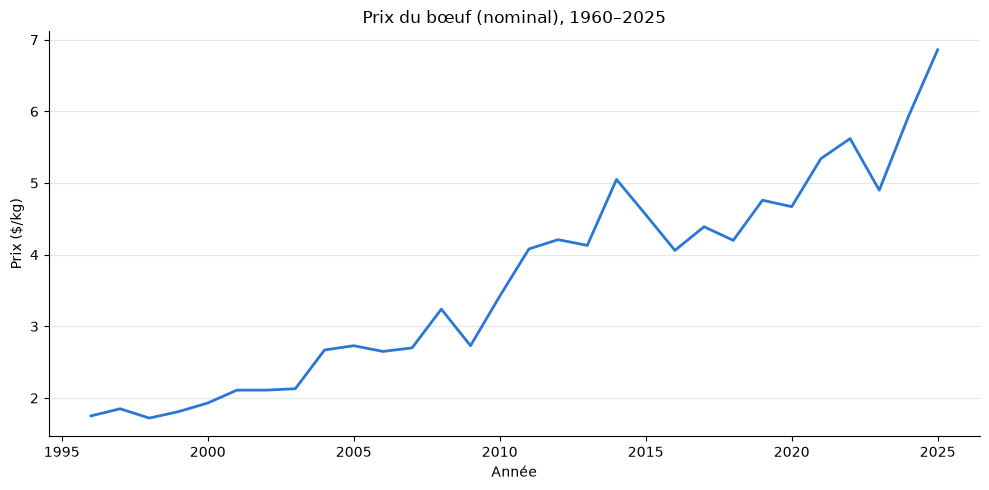

In [87]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Beef"], color="#2a78d6", linewidth=2)
ax.set_title("Prix du bœuf (nominal), 1960–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/kg)")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

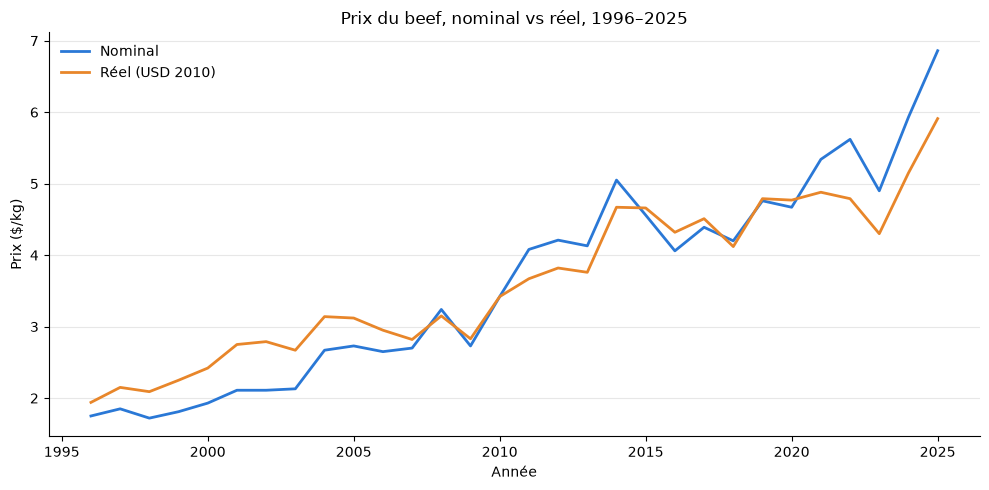

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df["year"], df["Beef"], color="#2a78d6", linewidth=2, label="Nominal")
ax.plot(df_real["year"], df_real["Beef"], color="#e8862a", linewidth=2, label="Réel (USD 2010)")
ax.set_title("Prix du beef, nominal vs réel, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/kg)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()





From here we start analysing price per country 


In [89]:
path = "../../data/raw/crops/FAOSTAT_2.0.csv"
price_data = pd.read_csv(path)
price_data.head() 


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Months Code,Months,Unit,Value,Flag,Flag Description
0,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1993,1993,7021,Annual value,USD,3116.2,A,Official value
1,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1994,1994,7021,Annual value,USD,2071.4,A,Official value
2,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1995,1995,7021,Annual value,USD,2481.2,A,Official value
3,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1996,1996,7021,Annual value,USD,2870.8,A,Official value
4,PP,Producer Prices,8,Albania,5532,Producer Price (USD/tonne),21111.01,"Meat of cattle with the bone, fresh or chilled",1997,1997,7021,Annual value,USD,2350.1,A,Official value


In [90]:
cattle = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Meat of cattle with the bone, fresh or chilled"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
cattle.head()



,Area,Item,Year,Unit,Value
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2


In [91]:
beef = df.loc[df["year"] >= 1996, ["year", "Beef"]]

cattle = cattle.merge(beef, left_on="Year", right_on="year", how="left").drop(columns="year")
cattle.head()


,Area,Item,Year,Unit,Value,Beef
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1.75
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1.85
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1.72
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1.81
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1.93


In [92]:

cattle["Beef"] = cattle["Beef"] * 1000
cattle = cattle.rename(columns={"Beef": "Prix mondial"})
cattle.head()


,Area,Item,Year,Unit,Value,Prix mondial
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1750.0
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1850.0
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1720.0
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1810.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1930.0


In [93]:
cattle["Difference"] = cattle["Value"] - cattle["Prix mondial"]
cattle.head()



,Area,Item,Year,Unit,Value,Prix mondial,Difference
0,Albania,"Meat of cattle with the bone, fresh or chilled",1996,USD,2870.8,1750.0,1120.8
1,Albania,"Meat of cattle with the bone, fresh or chilled",1997,USD,2350.1,1850.0,500.1
2,Albania,"Meat of cattle with the bone, fresh or chilled",1998,USD,3100.2,1720.0,1380.2
3,Albania,"Meat of cattle with the bone, fresh or chilled",1999,USD,3595.0,1810.0,1785.0
4,Albania,"Meat of cattle with the bone, fresh or chilled",2000,USD,3660.2,1930.0,1730.2


In [94]:
palm_oil = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Palm oil"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
palm_oil.head()


,Area,Item,Year,Unit,Value
0,Burundi,Palm oil,1996,USD,881.9
1,Burundi,Palm oil,1997,USD,1419.0
2,Burundi,Palm oil,1998,USD,1398.1
3,Burundi,Palm oil,1999,USD,824.3
4,Burundi,Palm oil,2000,USD,1317.7


In [95]:

palm_oil = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Palm oil"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)

palm = df.loc[df["year"] >= 1996, ["year", "Palm oil"]]
palm_oil = palm_oil.merge(palm, left_on="Year", right_on="year", how="left").drop(columns="year")
palm_oil = palm_oil.rename(columns={"Palm oil": "Prix mondial"})

palm_oil["Difference"] = palm_oil["Value"] - palm_oil["Prix mondial"]
palm_oil.head()




,Area,Item,Year,Unit,Value,Prix mondial,Difference
0,Burundi,Palm oil,1996,USD,881.9,531,350.9
1,Burundi,Palm oil,1997,USD,1419.0,546,873.0
2,Burundi,Palm oil,1998,USD,1398.1,671,727.1
3,Burundi,Palm oil,1999,USD,824.3,436,388.3
4,Burundi,Palm oil,2000,USD,1317.7,310,1007.7


In [96]:
soy = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Soya beans"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)
soy.head()

,Area,Item,Year,Unit,Value
0,Albania,Soya beans,1996,USD,478.5
1,Albania,Soya beans,1997,USD,335.7
2,Albania,Soya beans,1998,USD,331.9
3,Albania,Soya beans,1999,USD,435.8
4,Albania,Soya beans,2000,USD,487.1


In [97]:

soy = price_data.loc[
    (price_data["Year"] >= 1996)
    & (price_data["Item"] == "Soya beans"),
    ["Area", "Item", "Year", "Unit", "Value"]
].reset_index(drop=True)

soybeans = df.loc[df["year"] >= 1996, ["year", "Soybeans"]]
soy = soy.merge(soybeans, left_on="Year", right_on="year", how="left").drop(columns="year")
soy = soy.rename(columns={"Soybeans": "Prix mondial"})

soy["Difference"] = soy["Value"] - soy["Prix mondial"]

soy.head()


,Area,Item,Year,Unit,Value,Prix mondial,Difference
0,Albania,Soya beans,1996,USD,478.5,305,173.5
1,Albania,Soya beans,1997,USD,335.7,295,40.7
2,Albania,Soya beans,1998,USD,331.9,243,88.9
3,Albania,Soya beans,1999,USD,435.8,202,233.8
4,Albania,Soya beans,2000,USD,487.1,212,275.1


In [106]:
import country_converter as coco

for d in [cattle, soy, palm_oil]:
    if "ISO3" not in d.columns:
        pos = d.columns.get_loc("Area") + 1
        d.insert(pos, "ISO3", coco.convert(names=d["Area"], to="ISO3"))


pays_liste = ['Angola', 'Argentina', 'Australia', 'Bangladesh', 'Belize', 'Bolivia', 'Brazil', 'Bhutan',
              'Central African Republic', "Côte d'Ivoire", 'Cameroon', 'Democratic Republic of the Congo',
              'Republic of the Congo', 'Colombia', 'Costa Rica', 'Cuba', 'Dominican Republic', 'Ecuador',
              'Ethiopia', 'Fiji', 'Gabon', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Equatorial Guinea',
              'Guatemala', 'Guyana', 'Honduras', 'Indonesia', 'India', 'Kenya', 'Cambodia', 'Laos',
              'Liberia', 'Sri Lanka', 'Madagascar', 'Mexico', 'Myanmar', 'Mozambique', 'Malawi',
              'Malaysia', 'Nigeria', 'Nicaragua', 'Nepal', 'Panama', 'Peru', 'Philippines',
              'Papua New Guinea', 'Paraguay', 'Solomon Islands', 'Sierra Leone', 'South Sudan',
              'Suriname', 'Thailand', 'Taiwan', 'Tanzania', 'Uganda', 'Venezuela', 'Vietnam',
              'Vanuatu', 'South Africa', 'Zambia', 'Zimbabwe']

iso3_liste = coco.convert(names=pays_liste, to="ISO3")

cattle = cattle[cattle["ISO3"].isin(iso3_liste)].reset_index(drop=True)
soy = soy[soy["ISO3"].isin(iso3_liste)].reset_index(drop=True)
palm_oil = palm_oil[palm_oil["ISO3"].isin(iso3_liste)].reset_index(drop=True)

cattle.head()
soy.head()
palm_oil.head()

,Area,ISO3,Item,Year,Unit,Value,Prix mondial,Difference
0,Cameroon,CMR,Palm oil,1996,USD,567.8,531,36.8
1,Cameroon,CMR,Palm oil,1997,USD,562.5,546,16.5
2,Cameroon,CMR,Palm oil,1998,USD,571.9,671,-99.1
3,Cameroon,CMR,Palm oil,1999,USD,561.2,436,125.2
4,Cameroon,CMR,Palm oil,2000,USD,476.4,310,166.4


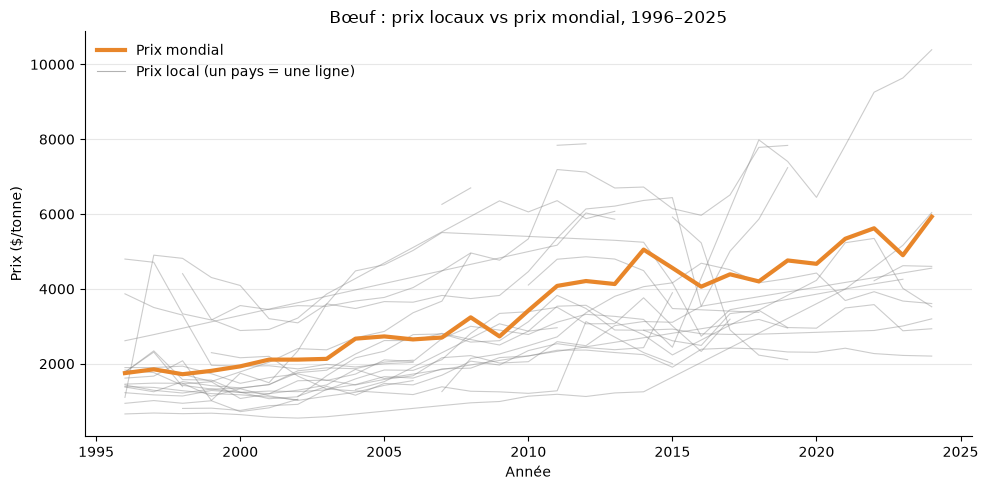

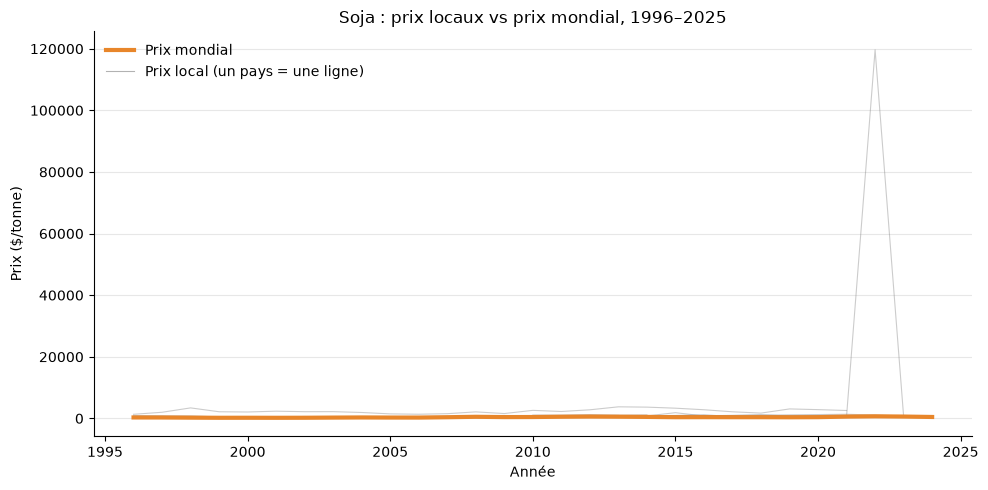

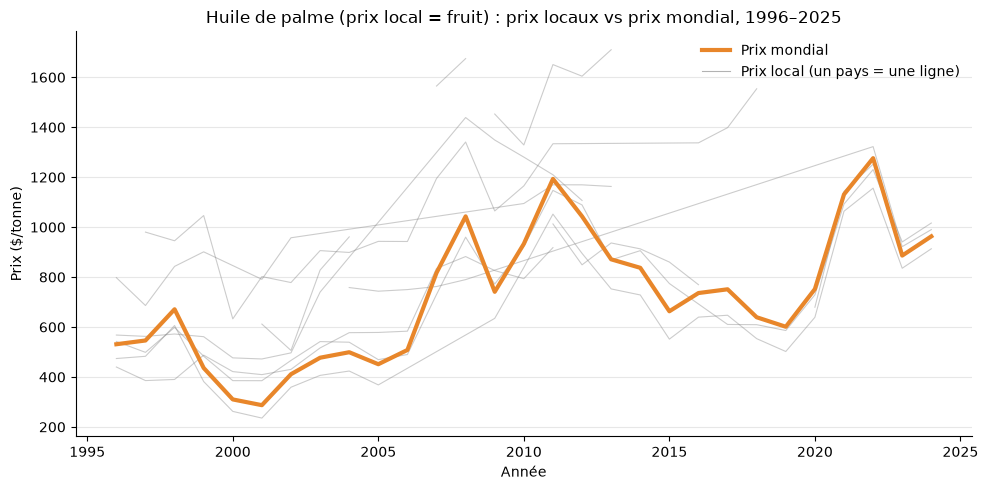

In [107]:
datasets = [
    (cattle, "Bœuf"),
    (soy, "Soja"),
    (palm_oil, "Huile de palme (prix local = fruit)"),
]

for data, titre in datasets:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Une ligne grise par pays
    for pays, d in data.groupby("Area"):
        d = d.sort_values("Year")
        ax.plot(d["Year"], d["Value"], color="grey", linewidth=0.8, alpha=0.4)

    # Prix mondial en couleur, par-dessus
    monde = data.drop_duplicates("Year").sort_values("Year")
    ax.plot(monde["Year"], monde["Prix mondial"], color="#e8862a", linewidth=3, label="Prix mondial")

    ax.plot([], [], color="grey", linewidth=0.8, alpha=0.6, label="Prix local (un pays = une ligne)")
    ax.set_title(f"{titre} : prix locaux vs prix mondial, 1996–2025")
    ax.set_xlabel("Année")
    ax.set_ylabel("Prix ($/tonne)")
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


In [111]:
for nom, d in [("cattle", cattle), ("soy", soy), ("palm_oil", palm_oil)]:
    print(nom, ":", d["Area"].nunique(), "pays")
    print(sorted(d["Area"].unique()), "\n")





cattle : 30 pays
['Argentina', 'Australia', 'Bangladesh', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', 'Congo', 'Dominican Republic', 'Fiji', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Honduras', 'Indonesia', 'Kenya', "Lao People's Democratic Republic", 'Madagascar', 'Malawi', 'Malaysia', 'Mozambique', 'Nicaragua', 'Nigeria', 'Peru', 'South Africa', 'Sri Lanka', 'Suriname', 'Viet Nam', 'Zambia'] 

soy : 33 pays
['Angola', 'Argentina', 'Australia', 'Bangladesh', 'Belize', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', "Côte d'Ivoire", 'Ecuador', 'Ethiopia', 'India', 'Indonesia', 'Kenya', "Lao People's Democratic Republic", 'Malawi', 'Nepal', 'Nicaragua', 'Nigeria', 'Paraguay', 'Peru', 'Philippines', 'South Africa', 'Sri Lanka', 'Suriname', 'Thailand', 'United Republic of Tanzania', 'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Zambia', 'Zimbabwe'] 

palm_oil : 12 pays
['Cameroon', 'Colombia', 'Congo', "Côte d'Ivoire", 'E

In [112]:
def garder_pays_10_ans(d, min_annees=10):
    n_annees = d.dropna(subset=["Value"]).groupby("Area")["Year"].nunique()
    pays_ok = n_annees[n_annees >= min_annees].index
    return d[d["Area"].isin(pays_ok)].reset_index(drop=True)

cattle = garder_pays_10_ans(cattle)
soy = garder_pays_10_ans(soy)
palm_oil = garder_pays_10_ans(palm_oil)

for nom, d in [("cattle", cattle), ("soy", soy), ("palm_oil", palm_oil)]:
    print(nom, ":", d["Area"].nunique(), "pays")


cattle : 19 pays
soy : 26 pays
palm_oil : 6 pays


In [118]:
sorted(cattle["Area"].unique())



['Australia',
 'Bhutan',
 'Brazil',
 'Colombia',
 'Congo',
 'Dominican Republic',
 'Fiji',
 'Guinea',
 'Kenya',
 'Malawi',
 'Malaysia',
 'Mozambique',
 'Nicaragua',
 'Nigeria',
 'Peru',
 'South Africa',
 'Sri Lanka',
 'Suriname',
 'Viet Nam']

In [122]:
sorted(soy["Area"].unique())

['Argentina',
 'Australia',
 'Bangladesh',
 'Bhutan',
 'Bolivia (Plurinational State of)',
 'Brazil',
 'Cambodia',
 'Colombia',
 'Ecuador',
 'Ethiopia',
 'India',
 'Indonesia',
 "Lao People's Democratic Republic",
 'Malawi',
 'Nepal',
 'Nicaragua',
 'Nigeria',
 'Paraguay',
 'Peru',
 'Philippines',
 'South Africa',
 'Sri Lanka',
 'Suriname',
 'Thailand',
 'Viet Nam',
 'Zimbabwe']

In [121]:
sorted(palm_oil["Area"].unique())

['Cameroon', 'Colombia', "Côte d'Ivoire", 'Ghana', 'Malaysia', 'Nigeria']

In [123]:
palm_oil.head()

,Area,ISO3,Item,Year,Unit,Value,Prix mondial,Difference
0,Cameroon,CMR,Palm oil,1996,USD,567.8,531,36.8
1,Cameroon,CMR,Palm oil,1997,USD,562.5,546,16.5
2,Cameroon,CMR,Palm oil,1998,USD,571.9,671,-99.1
3,Cameroon,CMR,Palm oil,1999,USD,561.2,436,125.2
4,Cameroon,CMR,Palm oil,2000,USD,476.4,310,166.4


In [127]:
indonesia_prix = {
    2001: 238.4,
    2002: 356.7,
    2003: 410.4,
    2004: 434.7,
    2005: 367.7,
    2006: 416.8,
    2007: 719.1,
    2008: 863.1,
    2009: 644.0,
    2010: 859.9,
    2011: 1076.5,
    2012: 939.8,
    2013: 764.2,
    2014: 739.4,
    2015: 565.1,
    2016: 639.8,
    2017: 647.8,
    2018: 559.9,
    2019: 524.0,
    2020: 666.1,
    2021: 769.7,
    2022: 823.9,
    2023: 737.7,

    

    # 2005: ...,
    # 2006: ...,
}

indonesia = pd.DataFrame({
    "Area": "Indonesia",
    "ISO3": "IDN",
    "Item": "Palm oil",
    "Year": list(indonesia_prix.keys()),
    "Unit": "USD",
    "Value": list(indonesia_prix.values()),
})

# Ajouter le prix mondial de la même année et la différence
indonesia = indonesia.merge(df[["year", "Palm oil"]], left_on="Year", right_on="year", how="left")
indonesia = indonesia.drop(columns="year").rename(columns={"Palm oil": "Prix mondial"})
indonesia["Difference"] = indonesia["Value"] - indonesia["Prix mondial"]

palm_oil = pd.concat([palm_oil, indonesia[palm_oil.columns]], ignore_index=True)
palm_oil[palm_oil["Area"] == "Indonesia"]


,Area,ISO3,Item,Year,Unit,Value,Prix mondial,Difference
111,Indonesia,IDN,Palm oil,2001,USD,238.4,287,-48.6
112,Indonesia,IDN,Palm oil,2002,USD,356.7,411,-54.3
113,Indonesia,IDN,Palm oil,2003,USD,410.4,477,-66.6
114,Indonesia,IDN,Palm oil,2004,USD,434.7,499,-64.3
115,Indonesia,IDN,Palm oil,2001,USD,238.4,287,-48.6
116,Indonesia,IDN,Palm oil,2002,USD,356.7,411,-54.3
117,Indonesia,IDN,Palm oil,2003,USD,410.4,477,-66.6
118,Indonesia,IDN,Palm oil,2004,USD,434.7,499,-64.3
119,Indonesia,IDN,Palm oil,2005,USD,367.7,451,-83.3
120,Indonesia,IDN,Palm oil,2006,USD,416.8,508,-91.2


In [128]:
palm_oil.head()

,Area,ISO3,Item,Year,Unit,Value,Prix mondial,Difference
0,Cameroon,CMR,Palm oil,1996,USD,567.8,531,36.8
1,Cameroon,CMR,Palm oil,1997,USD,562.5,546,16.5
2,Cameroon,CMR,Palm oil,1998,USD,571.9,671,-99.1
3,Cameroon,CMR,Palm oil,1999,USD,561.2,436,125.2
4,Cameroon,CMR,Palm oil,2000,USD,476.4,310,166.4


In [129]:
sorted(palm_oil["Area"].unique())

['Cameroon',
 'Colombia',
 "Côte d'Ivoire",
 'Ghana',
 'Indonesia',
 'Malaysia',
 'Nigeria']

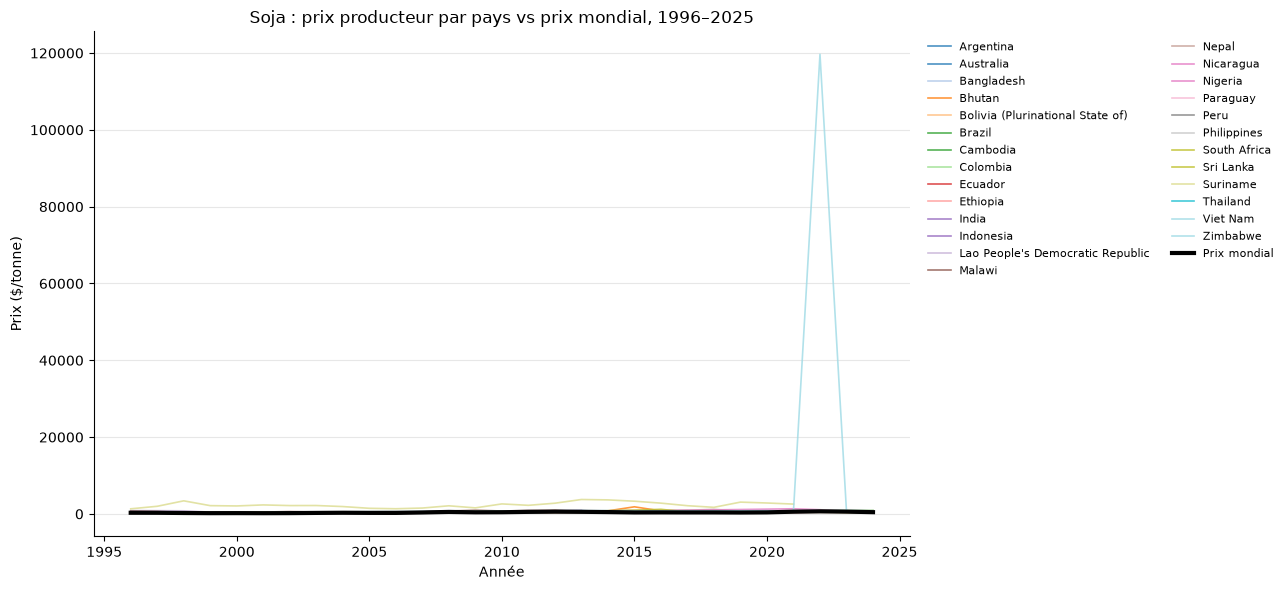

In [130]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(soy["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = soy[soy["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = soy.drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["Prix mondial"], color="black", linewidth=3, label="Prix mondial")

ax.set_title("Soja : prix producteur par pays vs prix mondial, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [131]:
masque = (soy["Area"] == "Zimbabwe") & (soy["Year"] == 2022)
soy.loc[masque, ["Value", "Difference"]] = np.nan

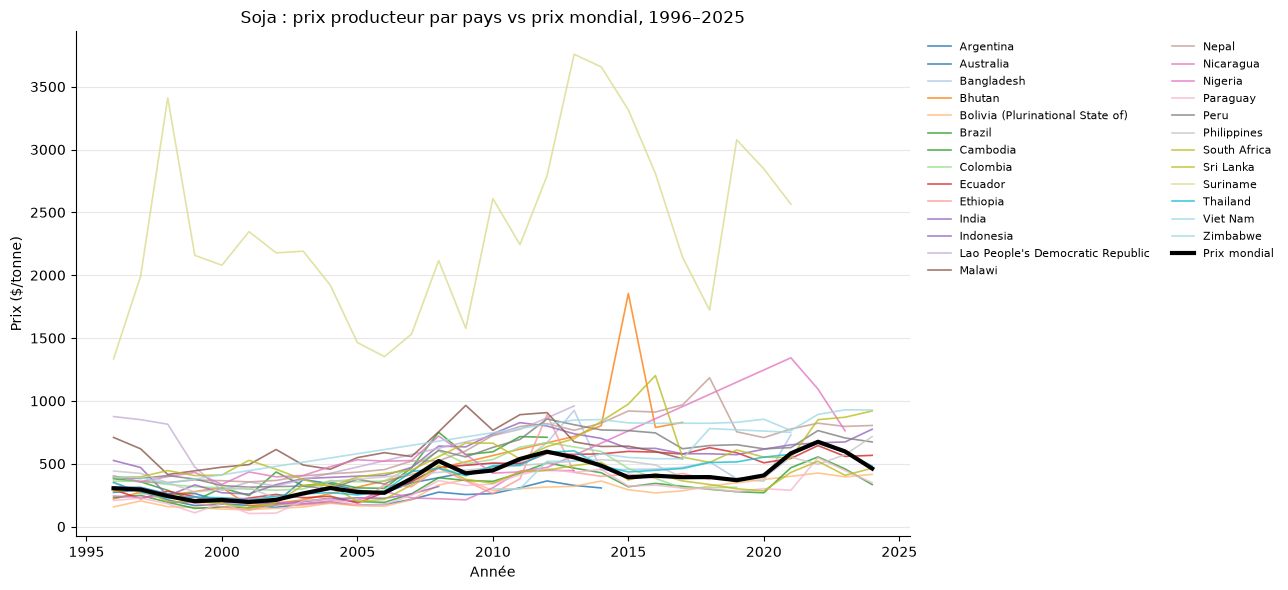

In [132]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(soy["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = soy[soy["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = soy.drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["Prix mondial"], color="black", linewidth=3, label="Prix mondial")

ax.set_title("Soja : prix producteur par pays vs prix mondial, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [133]:
soy = soy[soy["Area"] != "Suriname"].reset_index(drop=True)


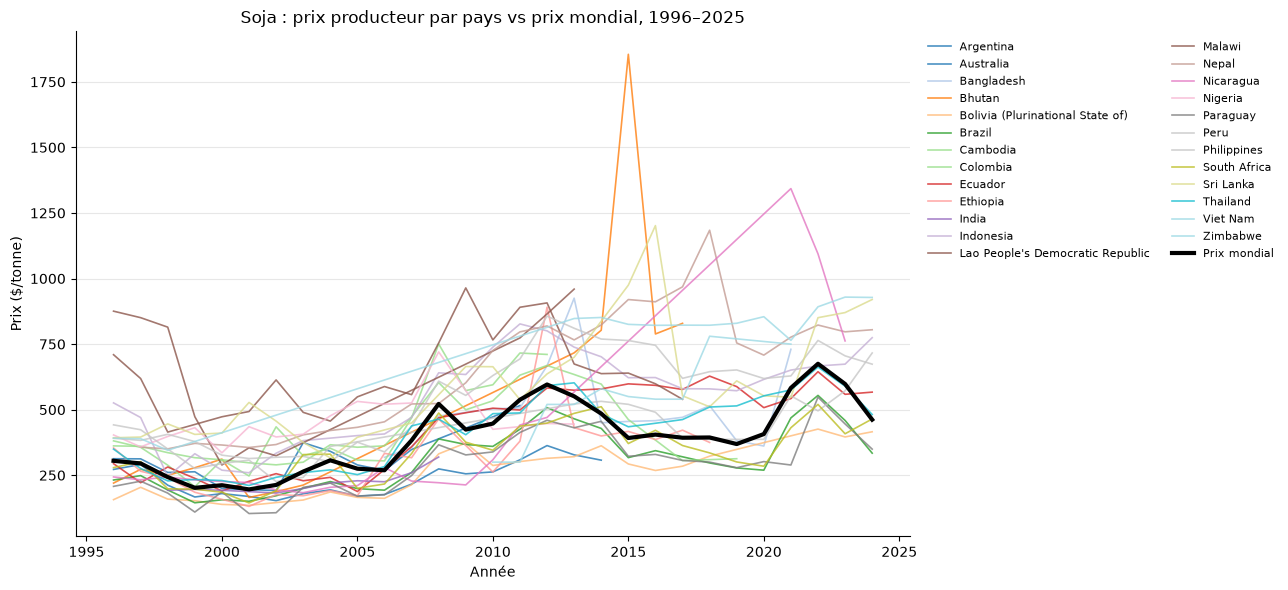

In [134]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(soy["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = soy[soy["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = soy.drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["Prix mondial"], color="black", linewidth=3, label="Prix mondial")

ax.set_title("Soja : prix producteur par pays vs prix mondial, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [140]:
argentina_prix = {
    2001: 770,
    2002: 480,
    2003: 640,
    2004: 680,
    2005: 770,
    2006: 760,
    2007: 850,
    2008: 930,
    2009: 860,
    2010: 1660,
    2011: 1980,
    2012: 1960,
    2013: 1770,
    2014: 1860,
    2015: 1920,
    2016: 1760,
    2017: 1760,
    2018: 1360,
    2019: 1365,
}

argentina = pd.DataFrame({
    "Area": "Argentina",
    "ISO3": "ARG",
    "Item": "Meat of cattle with the bone, fresh or chilled",
    "Year": list(argentina_prix.keys()),
    "Unit": "USD",
    "Value": list(argentina_prix.values()),
})

# Ajouter le prix mondial du bœuf (en $/tonne) et la différence
beef = df[["year", "Beef"]].assign(Beef=df["Beef"] * 1000)
argentina = argentina.merge(beef, left_on="Year", right_on="year", how="left")
argentina = argentina.drop(columns="year").rename(columns={"Beef": "Prix mondial"})
argentina["Difference"] = argentina["Value"] - argentina["Prix mondial"]

cattle = pd.concat([cattle, argentina[cattle.columns]], ignore_index=True)
cattle[cattle["Area"] == "Argentina"]


,Area,ISO3,Item,Year,Unit,Value,Prix mondial,Difference
350,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2001,USD,770.0,2110.0,-1340.0
351,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2002,USD,480.0,2110.0,-1630.0
352,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2003,USD,640.0,2130.0,-1490.0
353,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2004,USD,680.0,2670.0,-1990.0
354,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2005,USD,770.0,2730.0,-1960.0
355,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2006,USD,760.0,2650.0,-1890.0
356,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2007,USD,850.0,2700.0,-1850.0
357,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2008,USD,930.0,3240.0,-2310.0
358,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2009,USD,860.0,2730.0,-1870.0
359,Argentina,ARG,"Meat of cattle with the bone, fresh or chilled",2010,USD,1660.0,3420.0,-1760.0


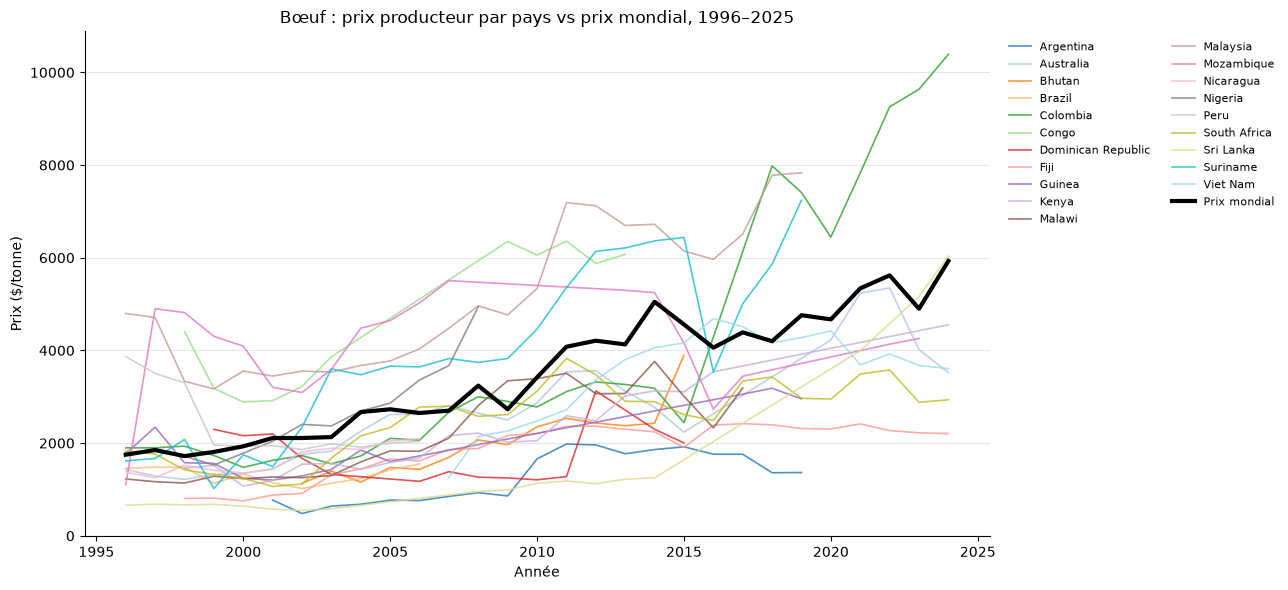

In [141]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(cattle["Area"].unique())
couleurs = plt.cm.tab20(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = cattle[cattle["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.2, alpha=0.8, label=p)

monde = cattle.dropna(subset=["Prix mondial"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["Prix mondial"], color="black", linewidth=3, label="Prix mondial")

ax.set_title("Bœuf : prix producteur par pays vs prix mondial, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/tonne)")
ax.legend(frameon=False, fontsize=8, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


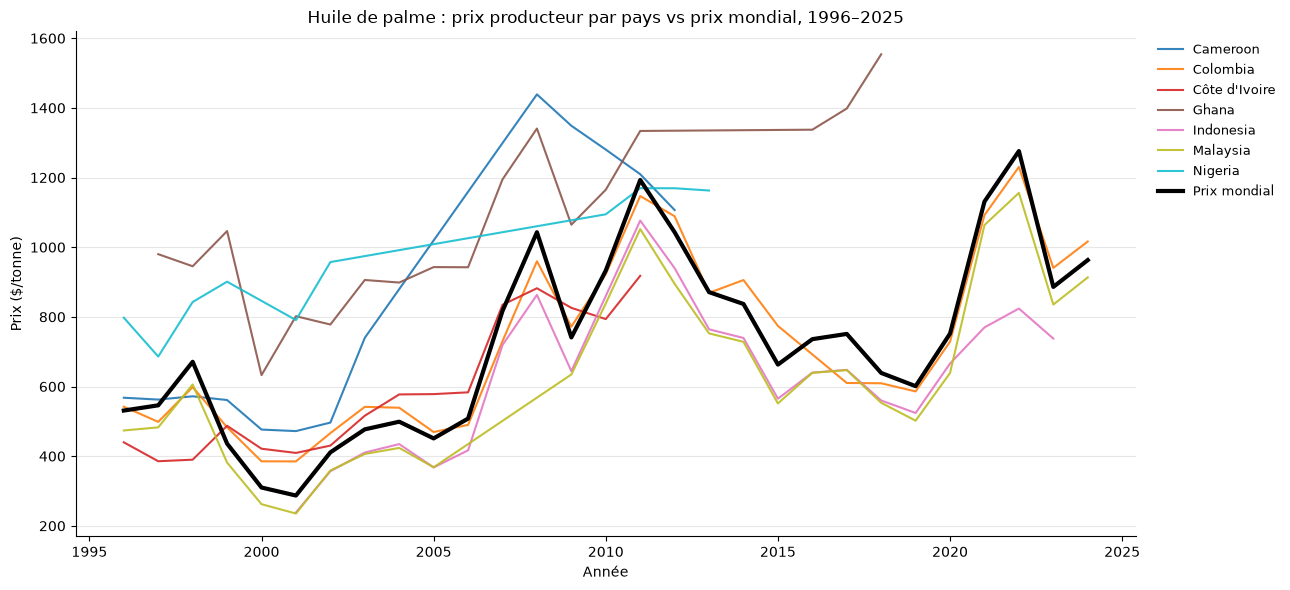

In [142]:
fig, ax = plt.subplots(figsize=(13, 6))

pays = sorted(palm_oil["Area"].unique())
couleurs = plt.cm.tab10(np.linspace(0, 1, len(pays)))

for p, c in zip(pays, couleurs):
    d = palm_oil[palm_oil["Area"] == p].sort_values("Year")
    ax.plot(d["Year"], d["Value"], color=c, linewidth=1.5, alpha=0.9, label=p)

monde = palm_oil.dropna(subset=["Prix mondial"]).drop_duplicates("Year").sort_values("Year")
ax.plot(monde["Year"], monde["Prix mondial"], color="black", linewidth=3, label="Prix mondial")

ax.set_title("Huile de palme : prix producteur par pays vs prix mondial, 1996–2025")
ax.set_xlabel("Année")
ax.set_ylabel("Prix ($/tonne)")
ax.legend(frameon=False, fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [143]:
for nom, d in [("cattle", cattle), ("soy", soy), ("palm_oil", palm_oil)]:
    pays = sorted(d["Area"].unique())
    print(f"{nom} : {len(pays)} pays")
    print(pays, "\n")



cattle : 20 pays
['Argentina', 'Australia', 'Bhutan', 'Brazil', 'Colombia', 'Congo', 'Dominican Republic', 'Fiji', 'Guinea', 'Kenya', 'Malawi', 'Malaysia', 'Mozambique', 'Nicaragua', 'Nigeria', 'Peru', 'South Africa', 'Sri Lanka', 'Suriname', 'Viet Nam'] 

soy : 25 pays
['Argentina', 'Australia', 'Bangladesh', 'Bhutan', 'Bolivia (Plurinational State of)', 'Brazil', 'Cambodia', 'Colombia', 'Ecuador', 'Ethiopia', 'India', 'Indonesia', "Lao People's Democratic Republic", 'Malawi', 'Nepal', 'Nicaragua', 'Nigeria', 'Paraguay', 'Peru', 'Philippines', 'South Africa', 'Sri Lanka', 'Thailand', 'Viet Nam', 'Zimbabwe'] 

palm_oil : 7 pays
['Cameroon', 'Colombia', "Côte d'Ivoire", 'Ghana', 'Indonesia', 'Malaysia', 'Nigeria'] 

